# NLP Lab Week 4 (Starter Code)
## Module 9: Comparing BERT, GPT-2, RoBERTa, and DistilBERT for Diabetes Prediction

## Learning Objectives

By the end of this module, **You** will be able to:

1. Serialise a tabular dataset into natural-language text for transformer input.
2. Understand the difference between encoder-only (BERT, RoBERTa, DistilBERT) and decoder-only (GPT-2) transformers.
3. Fine-tune pre-trained transformer models for binary classification using HuggingFace.
4. Train and evaluate multiple transformer architectures on the same task.
5. Compare model performance using standard classification metrics.
6. Interpret the strengths and limitations of large pre-trained models on small tabular datasets.

## Important Note

- The diabetes dataset used in this notebook is a **tabular dataset**, not a natural-language dataset.
- BERT, GPT-2, RoBERTa, and DistilBERT are pre-trained on text corpora. To apply them here, each row is **serialised** into a short descriptive string (e.g., `"Glucose: 148, BMI: 33.6, Age: 50, ..."`), which the tokeniser then processes.

> This serialisation is a valid and increasingly common technique (see: [TabLLM, 2022](https://arxiv.org/abs/2210.10723)), but it does **not** imply that the features have natural language structure. 


### Section 0: Set-up and Libraries
> Note the new libraries compared with Week 3: `transformers` and `AdamW`.

In [16]:
# Standard libraries
import time
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# HuggingFace Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification,logging
from torch.optim import AdamW

# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -----------------------------
# Device
# -----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# -----------------------------
# Hyperparameters (optimised for transformer fine-tuning)
# -----------------------------
MAX_LENGTH = 128          # avoids truncation of informative tokens
BATCH_SIZE = 16           # reduce to 8 if instability persists
NUM_EPOCHS = 4            # slightly longer training for stability

LR = 2e-5                 # standard BERT-family fine-tuning LR

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1        # 10% warmup steps
MAX_GRAD_NORM = 1.0       # gradient clipping (critical for stability)


Device: cpu


### Section 1: Load and Inspect the Dataset
> Download the diabetes CSV file from this [Kaggle Dataset](https://www.kaggle.com/datasets/pritsheta/diabetes-dataset) and place it in the same directory as this notebook.

Expected file: `diabetes.csv`

The dataset contains eight features:
- **Pregnancies** : number of times pregnant
- **Glucose** : plasma glucose concentration (2-h oral glucose tolerance test)
- **BloodPressure** : diastolic blood pressure (mm Hg)
- **SkinThickness** : triceps skinfold thickness (mm)
- **Insulin** : 2-h serum insulin (µU/ml)
- **BMI** : body mass index (kg/m²)
- **DiabetesPedigreeFunction** : genetic risk score based on family history
- **Age** : age in years

**Target Variable:** `Outcome` : binary label (0 = no diabetes, 1 = diabetes)

In [17]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

print('Shape:', df.shape)
display(df.head())
df.info()

# Separate features and target
feature_cols = [c for c in df.columns if c != 'Outcome']
X_df = df[feature_cols]
y    = df['Outcome'].values         # 0 or 1

print('\nClass distribution:')
print(pd.Series(y).value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))

# Train / test split  (80 / 20, stratified)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y,
    test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples: {len(y_train)}')
print(f'Test samples    : {len(y_test)}')


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Class distribution:
No Diabetes    500
Diabetes       268
Name: count, dtype: int64

Training samples: 614
Test samples    : 154


In [18]:
print(np.bincount(y_train))
print(np.bincount(y_test))

[400 214]
[100  54]


### Section 2: Text Serialisation, Dataset Class, and DataLoader Helper

Because transformer models expect **text** input, we convert each tabular row
into a natural-language string before tokenisation.

For example, a row with Glucose=148 and BMI=33.6 becomes:
```
"Pregnancies: 6, Glucose: 148, BloodPressure: 72, SkinThickness: 35, Insulin: 0, BMI: 33.6, DiabetesPedigreeFunction: 0.627, Age: 50"
```

> Note: unlike Week 3, we do **not** apply `StandardScaler` : the raw values are embedded directly in the text string.

This section defines three components:
1. **`serialise_row`** : converts a single tabular row to a text string.
2. **`TextDataset`** : a `torch.utils.data.Dataset` wrapping tokenised encodings and labels.
3. **`create_dataloaders`** : tokenises all rows and wraps them in `DataLoader` objects.


In [19]:
def serialise_row(row: pd.Series) -> str:
    """
    Convert a single tabular row into a descriptive text string.
    Integer-valued features are printed without a decimal point;
    float-valued features are rounded to two decimal places for readability.
    """
    parts = []
    for col, val in row.items():
        if isinstance(val, float) and val != int(val):
            parts.append(f'{col}: {val:.2f}')
        else:
            parts.append(f'{col}: {int(val)}')
    return ', '.join(parts)


# Serialise every row into a list of strings
train_texts = [serialise_row(row) for _, row in X_train_df.iterrows()]
test_texts  = [serialise_row(row) for _, row in X_test_df.iterrows()]

# Inspect a sample
print('Example serialised row:')
print(train_texts[0])
print('\nLabel:', y_train[0])


Example serialised row:
Pregnancies: 1, Glucose: 90, BloodPressure: 62, SkinThickness: 12, Insulin: 43, BMI: 27.20, DiabetesPedigreeFunction: 0.58, Age: 24

Label: 0


In [20]:
class TextDataset(Dataset):
    """
    PyTorch Dataset wrapping tokenised text encodings and integer labels.

    Parameters
    ----------
    encodings : BatchEncoding
        Output of a HuggingFace tokeniser (dict-like with 'input_ids',
        'attention_mask', and optionally 'token_type_ids').
    labels : torch.Tensor
        1-D long tensor of class labels (already converted in create_dataloaders).
    """

    def __init__(self, encodings, labels: torch.Tensor):
        # store tokenised inputs (e.g., input_ids, attention_mask)
        self.encodings = encodings
        # store labels safely: clone avoids shared reference,
        # detach removes them from any computation graph
        self.labels = labels.clone().detach() 

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Build item dict from tokeniser outputs
        # retrieve a single training example from tokenised encodings
        item = {
            'input_ids'     : torch.tensor(self.encodings['input_ids'][idx],      dtype=torch.long),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx], dtype=torch.long),
        }
        # add token_type_ids only if the model supports segment embeddings (e.g. BERT)
        if 'token_type_ids' in self.encodings:
            item['token_type_ids'] = torch.tensor(self.encodings['token_type_ids'][idx], dtype=torch.long)
        # attach corresponding label
        item['labels'] = self.labels[idx]
        return item


In [21]:
def create_dataloaders(tokenizer, train_texts, y_train,
                        test_texts, y_test,
                        max_length=MAX_LENGTH,
                        batch_size=BATCH_SIZE):

    # Convert labels to tensors HERE (single conversion point).
    # TextDataset will use .clone().detach() : not torch.tensor() : so no double-wrap.
    y_train_t = torch.tensor([int(y) for y in y_train], dtype=torch.long)
    y_test_t  = torch.tensor([int(y) for y in y_test],  dtype=torch.long)

    train_enc = tokenizer(
        train_texts,
        truncation=True,
        padding='max_length',
        max_length=max_length
    )

    test_enc = tokenizer(
        test_texts,
        truncation=True,
        padding='max_length',
        max_length=max_length
    )

    train_loader = DataLoader(
        TextDataset(train_enc, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        TextDataset(test_enc, y_test_t),
        batch_size=batch_size,
        shuffle=False
    )

    # Also return y_train_t so train_model can compute class weights
    return train_loader, test_loader, y_train_t


### Section 3: Tokenisers and DataLoaders
Have a look at [Hugging Face LLM courses](https://huggingface.co/learn/llm-course/chapter1/1). I highly **recommend** these courses and **encourage** you to obtain the corresponding certifications as well.
- Each transformer model uses its own tokeniser.
- [GPT-2](https://huggingface.co/docs/transformers/en/model_doc/gpt2) was pre-trained without a dedicated padding token; we assign the end-of-sequence token as a stand-in.


In [22]:
# ── BERT ──────────────────────────────────────────────────────────────────
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_train_loader, bert_test_loader, bert_y_train = create_dataloaders(
    bert_tokenizer, train_texts, y_train, test_texts, y_test
)

# ── GPT-2 ─────────────────────────────────────────────────────────────────
gpt2_tokenizer = AutoTokenizer.from_pretrained('gpt2')
# GPT-2 has no pad token; use the end-of-sequence (EOS) token as padding
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_train_loader, gpt2_test_loader, gpt2_y_train = create_dataloaders(
    gpt2_tokenizer, train_texts, y_train, test_texts, y_test
)

# ── RoBERTa ───────────────────────────────────────────────────────────────
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
roberta_train_loader, roberta_test_loader, roberta_y_train = create_dataloaders(
    roberta_tokenizer, train_texts, y_train, test_texts, y_test
)

# ── DistilBERT ────────────────────────────────────────────────────────────
distilbert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_train_loader, distilbert_test_loader, distilbert_y_train = create_dataloaders(
    distilbert_tokenizer, train_texts, y_train, test_texts, y_test
)
print('All tokenisers and DataLoaders created.')


All tokenisers and DataLoaders created.


### Section 4: Model 1 : BERT

**bert-base-uncased** : 12 encoder layers, ~110 M parameters, bidirectional.
Pre-trained on BookCorpus + Wikipedia using masked language modelling (MLM)
and next-sentence prediction (NSP).
`AutoModelForSequenceClassification` adds a linear head on top of the `[CLS]` token
and is fine-tuned end-to-end.


In [23]:
logging.set_verbosity_error() # hides the warnings while keeping the correct behaviour.
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,   # binary: No Diabetes (0) / Diabetes (1)
).to(device)

print(bert_model.config)
total = sum(p.numel() for p in bert_model.parameters())
print(f'\nTotal parameters: {total:,}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.11.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}


Total parameters: 109,483,778


### Section 5: Model 2 : GPT-2

**gpt2** : 12 decoder layers, ~117 M parameters, unidirectional (left-to-right).
Pre-trained on WebText using causal language modelling.
Because classification requires pooling over a sequence and GPT-2 has no `[CLS]` token,
HuggingFace uses the representation of the **last non-padding token** instead.

> The `pad_token_id` in the model config must match the tokeniser fix applied in Section 3
> so that the model correctly ignores padding positions.


In [24]:
logging.set_verbosity_error() # hides the warnings while keeping the correct behaviour.
gpt2_model = AutoModelForSequenceClassification.from_pretrained(
    'gpt2',
    num_labels=2,
).to(device)

# Mirror the tokeniser pad-token fix in the model config
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

print(gpt2_model.config)
print(f'\nTotal parameters: {sum(p.numel() for p in gpt2_model.parameters()):,}')


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": 50256,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.11.0",
  "use_cache": true,
  "vocab_size": 50257
}


Total parameters: 124,441

### Section 6: Model 3 : RoBERTa

**roberta-base** : 12 encoder layers, ~125 M parameters.
An optimised re-training of BERT with byte-level BPE tokenisation,
dynamic masking, and without Next-Sentence Prediction (NSP).
Typically outperforms BERT on downstream tasks with the same architecture.


In [25]:
logging.set_verbosity_error() # hides the warnings while keeping the correct behaviour.
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
).to(device)

print(roberta_model.config)
print(f'\nTotal parameters: {sum(p.numel() for p in roberta_model.parameters()):,}')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "transformers_version": "5.11.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}


Total parameters: 124,647,170


### Section 7: Model 4 : DistilBERT

**distilbert-base-uncased** : 6 encoder layers, ~66 M parameters.
A compressed version of BERT obtained through knowledge distillation:
40 % fewer parameters, ~60 % faster inference, retaining ~97 % of BERT's
performance on GLUE benchmarks.


In [26]:
logging.set_verbosity_error() # hides the warnings while keeping the correct behaviour.
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
).to(device)

print(distilbert_model.config)
print(f'\nTotal parameters: {sum(p.numel() for p in distilbert_model.parameters()):,}')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.11.0",
  "vocab_size": 30522
}


Total parameters: 66,955,010


### Section 8: Training Function

Fine-tuning uses `CrossEntropyLoss` (two logits, one per class) instead of
`BCEWithLogitsLoss` (one logit) used in Week 3.
The `AdamW` optimiser with weight decay is the standard choice for transformer fine-tuning;
it decouples weight decay from the adaptive learning-rate update.


In [27]:
from transformers import get_linear_schedule_with_warmup

def train_model(model, train_loader, y_train_labels,
                num_epochs=NUM_EPOCHS, lr=LR):
    """
    Fine-tune a transformer model for binary classification.

    Improvements included:
    - class weighting to handle class imbalance
    - learning-rate warmup for stable optimisation
    - gradient clipping to prevent exploding gradients
    """

    # --------------------------------------------------
    # Compute class weights
    # --------------------------------------------------
    # Count how many samples belong to each class.
    # Dummy Example:
    # Class 0 (No Diabetes) = 400 samples
    # Class 1 (Diabetes) = 100 samples
    class_counts = torch.bincount(y_train_labels).float()

    # Assign higher importance to minority classes.
    # We use the inverse square root instead of a full inverse
    # to avoid extremely large weights.
    class_weights = 1.0 / torch.sqrt(class_counts)

    # Move weights to GPU (or CPU) where the model is located.
    class_weights = class_weights.to(device)

    # Display the calculated weights.
    print(
        f'Class weights → '
        f'No Diabetes: {class_weights[0]:.4f}, '
        f'Diabetes: {class_weights[1]:.4f}'
    )

    # Cross-entropy loss with class weighting.
    # Misclassifying the minority class will now incur
    # a larger penalty.
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # AdamW is the standard optimiser for transformer models.
    # Weight decay acts as regularisation and helps reduce
    # overfitting.
    optimizer = AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

    # --------------------------------------------------
    # Learning-rate scheduler
    # --------------------------------------------------
    # Total number of parameter updates during training.
    total_steps = len(train_loader) * num_epochs

    # Warmup phase:
    # Gradually increase the learning rate at the beginning
    # of training rather than starting with the full value.
    warmup_steps = int(WARMUP_RATIO * total_steps)

    # Linear schedule:
    # 1. Increase learning rate during warmup.
    # 2. Gradually decrease it afterwards.
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Put the model into training mode.
    model.train()

    # Store loss values for later visualisation.
    losses = []

    # Record training start time.
    start_time = time.time()

    # --------------------------------------------------
    # Main training loop
    # --------------------------------------------------
    for epoch in range(num_epochs):

        # Accumulate batch losses across the epoch.
        epoch_loss = 0.0

        # Iterate through mini-batches.
        for batch in train_loader:

            # Move inputs to the selected device.
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Reset gradients from the previous batch.
            optimizer.zero_grad()

            # Forward pass:
            # Generate predictions from the transformer.
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # Compare predictions against true labels.
            loss = criterion(outputs.logits, labels)

            # Backward pass:
            # Compute gradients for all trainable parameters.
            loss.backward()

            # --------------------------------------------------
            # Gradient clipping
            # --------------------------------------------------
            # Prevents excessively large gradients which can
            # destabilise training and cause loss explosions.
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )

            # Update model weights.
            optimizer.step()

            # Update learning rate according to the schedule.
            scheduler.step()

            # Accumulate loss for reporting.
            epoch_loss += loss.item()

        # Average loss across all batches in this epoch.
        avg_loss = epoch_loss / len(train_loader)

        # Store the loss history.
        losses.append(avg_loss)

        # Display epoch progress.
        print(
            f"Epoch {epoch + 1}/{num_epochs} "
            f"loss={avg_loss:.4f}"
        )

    # Total training time in seconds.
    training_time = time.time() - start_time

    return losses, training_time

### Section 9: Evaluation and Confusion Matrix Functions

Key differences from Week 3's evaluation:
- Logits are converted to class probabilities using **softmax** (not sigmoid),
  because the model outputs two logits (one per class).
- Class predictions are the **argmax** of the logits.
- `roc_auc_score` receives `probabilities[:, 1]` : the probability of the positive class.
- Precision, recall, and F1 use sklearn's default `average='binary'` setting,
  which is correct for two-class problems.


In [28]:
def evaluate_model(model, test_loader):
    """
    Evaluate a fine-tuned transformer on the test DataLoader.
    Collects logits from all batches before computing metrics.

    Returns a dict with Accuracy, Precision, Recall, F1, ROC_AUC.
    """
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_logits.append(outputs.logits.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0)   # shape: (N, 2)
    all_labels = torch.cat(all_labels, dim=0).numpy()

    # Softmax → probability of each class; shape: (N, 2)
    probabilities = torch.softmax(all_logits, dim=1).numpy()

    predictions = (probabilities[:, 1] > 0.5).astype(int)

    # Standard binary classification metrics
    # (sklearn default average='binary' is correct for two-class problems)
    return {
        'Accuracy' : accuracy_score( all_labels, predictions),
        'Precision': precision_score(all_labels, predictions, zero_division=0),
        'Recall'   : recall_score(   all_labels, predictions, zero_division=0),
        'F1'       : f1_score(       all_labels, predictions, zero_division=0),
        # ROC-AUC uses probability of the POSITIVE class (column 1)
        'ROC_AUC'  : roc_auc_score(  all_labels, probabilities[:, 1]),
    }


def plot_confusion_matrix(model, test_loader, name):
    """
    Plot a 2x2 confusion matrix with class names for binary classification.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = outputs.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(
        all_labels, all_preds,
        display_labels=['No Diabetes', 'Diabetes'],
        colorbar=False, ax=ax
    )
    ax.set_title(f'{name}: Confusion Matrix')
    plt.tight_layout()
    plt.show()

### Section 10: Training all Models
> Training four large pre-trained models will take significant time on CPU.
> For faster runtimes, use a GPU runtime (e.g. Google Colab with a T4).


 Training BERT
Class weights → No Diabetes: 0.0500, Diabetes: 0.0684
Epoch 1/4 loss=0.6771
Epoch 2/4 loss=0.6568
Epoch 3/4 loss=0.6469
Epoch 4/4 loss=0.6209


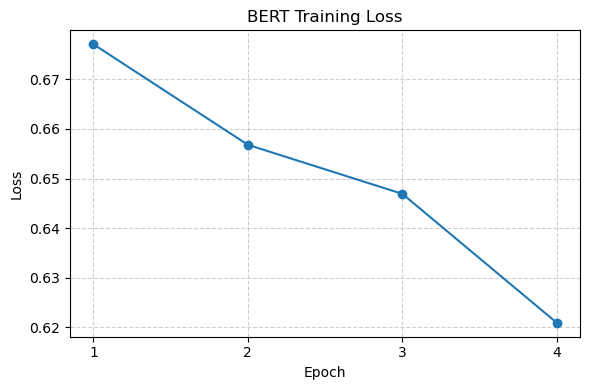

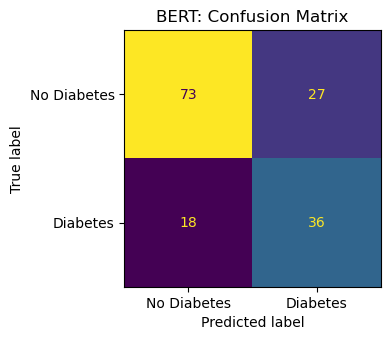


 Training GPT-2
Class weights → No Diabetes: 0.0500, Diabetes: 0.0684


In [ ]:
results = []

# Each entry: model instance, train DataLoader, test DataLoader, label tensor
# y_train tensor is passed to train_model for class-weight computation
models = {
    'BERT'      : (bert_model,       bert_train_loader,       bert_test_loader,       bert_y_train),
    'GPT-2'     : (gpt2_model,       gpt2_train_loader,       gpt2_test_loader,       gpt2_y_train),
    'RoBERTa'   : (roberta_model,    roberta_train_loader,    roberta_test_loader,    roberta_y_train),
    'DistilBERT': (distilbert_model, distilbert_train_loader, distilbert_test_loader, distilbert_y_train)
}

for name, (mdl, train_loader, test_loader, y_train_t) in models.items():

    print(f'\n{"="*50}')
    print(f' Training {name}')
    print(f'{"="*50}')

    losses, train_time = train_model(mdl, train_loader, y_train_t)

    metrics = evaluate_model(mdl, test_loader)
    metrics['Model']              = name
    metrics['Training Time (s)'] = round(train_time, 2)
    results.append(metrics)

    # Training loss curve : one plot per model (mirrors Week 3 style)
    plt.figure(figsize=(6, 4))
    plt.plot(losses, marker='o')
    plt.title(f'{name} Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(range(NUM_EPOCHS), range(1, NUM_EPOCHS + 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Confusion matrix right after the loss curve (mirrors Week 3 style)
    plot_confusion_matrix(mdl, test_loader, name)


### Section 11: Result Analysis of all Models
> Code for results analysis

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df[
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Training Time (s)']
]

# Sort by Accuracy descending : same ordering as Week 3
results_df.sort_values(by='Accuracy', ascending=False)


## Reflection Questions

1. What is the role of the `[CLS]` token in BERT-based classification, and why does GPT-2 use the last non-padding token instead?
 - Answer: BERT looks at the whole sentence in both directions, so the [CLS] token ends up summarizing the whole sentence, that's what gets used for classification. GPT-2 only looks backward, so only the last token has seen the entire sentence, that's why it's used instead.
2. What is the key architectural difference between BERT/RoBERTa (encoder-only) and GPT-2 (decoder-only)? How does this affect their suitability for classification?
 - Answer: BERT/RoBERTa read text in both directions at once that is bidirectional, so they are great for classification. GPT-2 reads only left-to-right like predicting the next word, so it's naturally built for text generation, not classification. It can still be used for classification, but it's a bit less efficient at it.
3. Why does GPT-2 require the padding token fix (`gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token` and `gpt2_model.config.pad_token_id = ...`)? What would happen without it?
 - Answer: GPT-2 was not trained with a padding token, so it doesn't have one by default. But to batch sentences of different lengths together, we need padding. The fix just tells GPT-2 "use the EOS token as padding." Without this fix, the code would crash with an error when trying to pad the inputs. 
4. Compare the training setup with Week 3: Week 3 used 50 epochs with Adam (lr=0.001); Week 4 uses 4 epochs with AdamW (lr=2e-5). Why do pre-trained transformers require fewer epochs and a lower learning rate?
 - Answer: In Week 3, the model started from scratch, so it needed lots of training to learn everything. In Week 4, the models are already pre-trained, so we just need to gently fine tune them with a few epochs and a tiny learning rate. Big updates would mess up the useful knowledge they already have.
5. What is the computational trade-off between DistilBERT and BERT? Given your results, was the accuracy trade-off acceptable?
 - Answer: DistilBERT is smaller and faster but slightly less accurate — usually only a small drop in performance. Since the speed and memory savings are big and the accuracy loss is small, DistilBERT is usually a good trade-off, especially for small tasks.
6. The diabetes dataset has only 614 training samples. What risks does this pose when fine-tuning models with 66:125 million parameters? What strategies could mitigate these risks? (Hint: Think of overfitting and performane estimates)
 - Answer: Risk: the model is so big compared to the tiny dataset that it can memorize the training data instead of learning general patterns (overfitting), and test results can be unreliable since the test set is small.
